In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, make_circles, make_blobs

In [2]:
def get_moons(batch_size=256):
    X, _ = make_moons(n_samples=3000, noise=0.05)
    X = torch.FloatTensor(X)
    dataset = TensorDataset(X)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def get_circles(batch_size=256):
    X,_=make_circles(n_samples=3000,noise=0.05)
    X=torch.FloatTensor(X)
    dataset=TensorDataset(X)
    return DataLoader(dataset, batch_size=batch_size,shuffle=True)

# def get_blobs(batch_size=256):
#     X,_=make_blobs(n_samples=3000)
#     X=torch.FloatTensor(X)
#     dataset=TensorDataset(X)
#     return DataLoader(dataset, batch_size=batch_size,shuffle=True)

In [3]:
class LinearVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            # nn.ReLU() #adding a non linearity here makes the model worse
        )

        self.mu_layer = nn.Linear(64, latent_dim)
        self.logvar_layer = nn.Linear(64, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [4]:
def vae_loss(recon_x, x, mu, logvar, epoch):
    # Term 1: Reconstruction loss (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    beta=0.02 # The best generation that occured is here above this the 2 moons combine to form a wave lowering makes even more points in the part between the halves
    # Term 2: KL divergence from N(0, I)
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta*kl_loss, recon_loss, kl_loss

In [5]:
def train_vae(model, train_loader, epochs=200, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = total_recon = total_kl = 0

        for batch in train_loader:
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            recon_x, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon_x, x, mu, logvar, epoch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | Loss: {total_loss:.2f} | Recon: {total_recon:.2f} | KL: {total_kl:.2f}")

In [6]:
def plot_reconstructions(model, data, n=10):
    with torch.no_grad():
        recon, _, _ = model(data[:n])

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.scatter(data[:n, 0], data[:n, 1], c='blue', alpha=0.6)
    plt.title('Original Data')
    plt.subplot(1, 2, 2)
    plt.scatter(recon[:, 0], recon[:, 1], c='red', alpha=0.6)
    plt.title('Reconstructed Data')
    plt.show()

In [7]:
def plot_latent_space(model, data):
    with torch.no_grad():
        mu, logvar = model.encode(data)

    plt.figure(figsize=(6, 6))
    plt.scatter(mu[:, 0], mu[:, 1], alpha=0.5, s=10)
    plt.xlabel('Latent dim 1')
    plt.ylabel('Latent dim 2')
    plt.title('Latent Space')
    plt.grid(True, alpha=0.3)
    plt.show()

In [8]:
def plot_generated(model, n=1000):
    with torch.no_grad():
        z = torch.randn(n, 2)   # Sample from N(0, I)
        samples = model.decode(z)

    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=5)
    plt.title('Generated Samples -- Pure Creation from Noise')
    plt.grid(True, alpha=0.3)
    plt.show()

In [9]:
vae=LinearVAE()
vae1=LinearVAE()

In [10]:
data=get_moons()
train_vae(vae1,data,300,1e-2)

Epoch   0 | Loss: 2559.58 | Recon: 2448.19 | KL: 5569.49
Epoch  20 | Loss: 274.66 | Recon: 67.22 | KL: 10371.99
Epoch  40 | Loss: 264.52 | Recon: 61.53 | KL: 10149.43
Epoch  60 | Loss: 264.77 | Recon: 62.37 | KL: 10119.83
Epoch  80 | Loss: 262.78 | Recon: 66.93 | KL: 9792.84
Epoch 100 | Loss: 259.51 | Recon: 60.51 | KL: 9950.02
Epoch 120 | Loss: 256.30 | Recon: 60.84 | KL: 9773.03
Epoch 140 | Loss: 258.53 | Recon: 60.00 | KL: 9926.50
Epoch 160 | Loss: 257.16 | Recon: 61.94 | KL: 9761.26
Epoch 180 | Loss: 256.91 | Recon: 61.28 | KL: 9781.39
Epoch 200 | Loss: 256.10 | Recon: 60.59 | KL: 9775.70
Epoch 220 | Loss: 255.42 | Recon: 58.19 | KL: 9861.79
Epoch 240 | Loss: 256.51 | Recon: 61.80 | KL: 9735.12
Epoch 260 | Loss: 256.90 | Recon: 63.21 | KL: 9684.49
Epoch 280 | Loss: 258.70 | Recon: 67.21 | KL: 9574.10


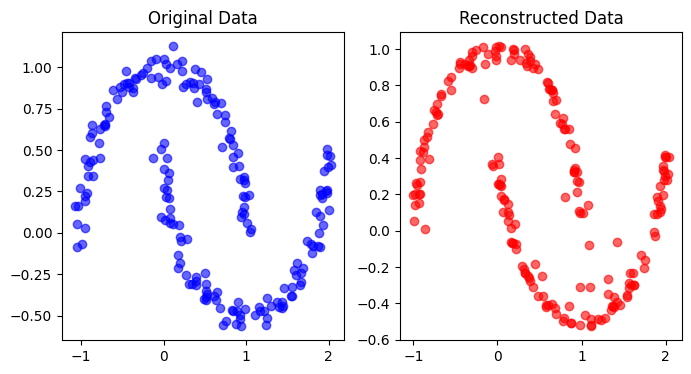

In [11]:
X,_=make_moons(n_samples=200,noise=0.05)
X=torch.FloatTensor(X)
plot_reconstructions(vae1,X,n=500)

In [12]:
data2=get_circles()
train_vae(vae,data2,300,1e-2)
Y,_=make_circles(n_samples=200,noise=0.05)
Y=torch.FloatTensor(Y)

Epoch   0 | Loss: 1679.21 | Recon: 1599.75 | KL: 3973.08
Epoch  20 | Loss: 269.64 | Recon: 68.96 | KL: 10034.03
Epoch  40 | Loss: 272.08 | Recon: 71.70 | KL: 10019.00
Epoch  60 | Loss: 272.64 | Recon: 72.73 | KL: 9995.76
Epoch  80 | Loss: 269.74 | Recon: 70.17 | KL: 9978.74
Epoch 100 | Loss: 274.10 | Recon: 74.89 | KL: 9960.70
Epoch 120 | Loss: 271.63 | Recon: 72.01 | KL: 9980.97
Epoch 140 | Loss: 270.40 | Recon: 71.64 | KL: 9937.76
Epoch 160 | Loss: 270.98 | Recon: 72.14 | KL: 9941.81
Epoch 180 | Loss: 269.17 | Recon: 73.84 | KL: 9766.43
Epoch 200 | Loss: 270.80 | Recon: 71.49 | KL: 9965.33
Epoch 220 | Loss: 270.32 | Recon: 71.49 | KL: 9941.55
Epoch 240 | Loss: 270.48 | Recon: 70.88 | KL: 9979.89
Epoch 260 | Loss: 268.34 | Recon: 71.05 | KL: 9864.39
Epoch 280 | Loss: 272.03 | Recon: 72.19 | KL: 9991.96


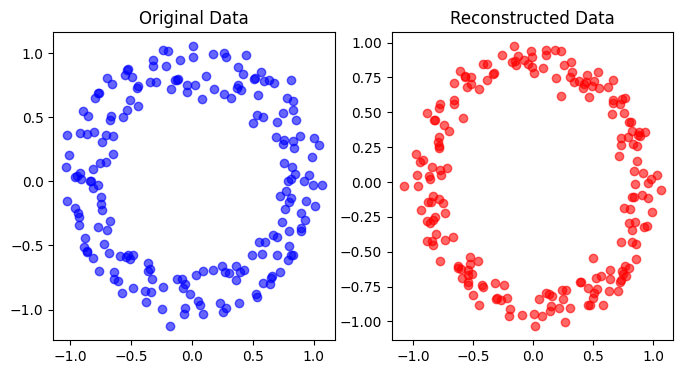

In [13]:
plot_reconstructions(vae,Y,n=200)

In [14]:
with torch.no_grad():
    mu,logvar=vae.encode(X)
print(mu.std(0))
print(logvar.mean())

tensor([1.2828, 0.8811])
tensor(-3.3322)


In [15]:
with torch.no_grad():
    mu,logvar=vae.encode(Y)
print(mu.std(0))
print(logvar.mean())

tensor([0.9996, 0.9678])
tensor(-3.3609)


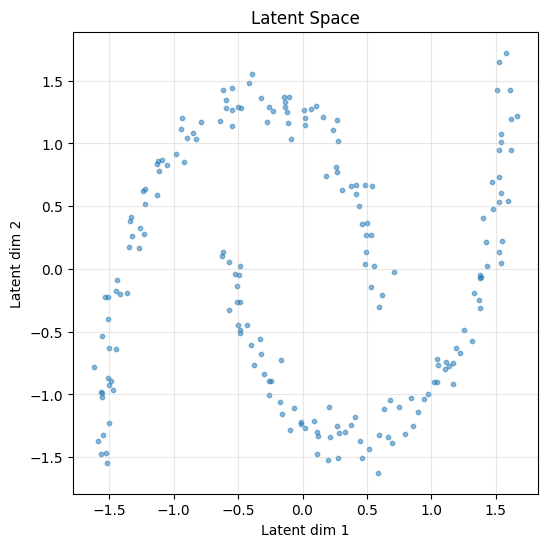

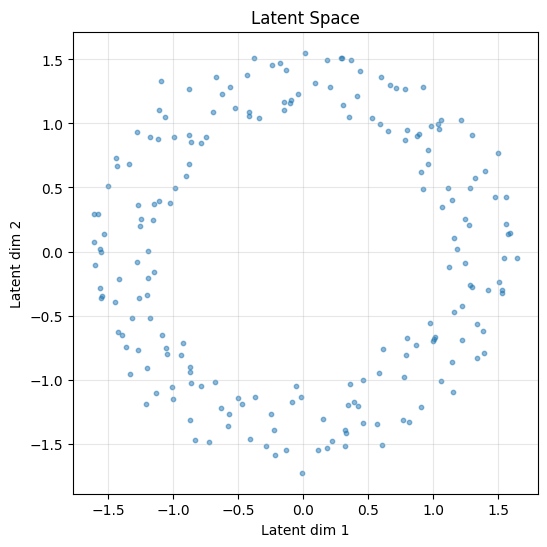

In [16]:
plot_latent_space(vae1,X)
plot_latent_space(vae,Y)

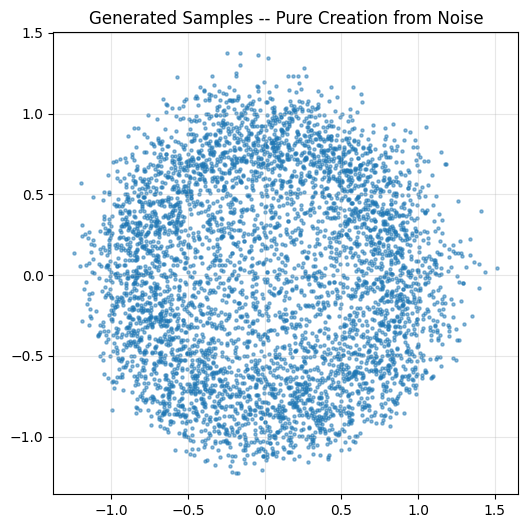

In [17]:
plot_generated(vae,5000)

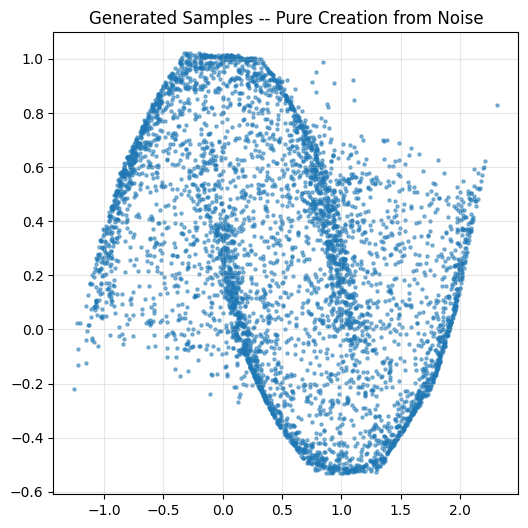

In [18]:
plot_generated(vae1,5000)